# GloVe (Global Vectors)

Statistika pojavljivanja reči u korpusu predstavlja osnovnu informaciju koja je dostupna metodama nenadgledanog učenja za reprezentaciju reči. Postavilo se pitanje - Kako se iz ove statistike generiše značenje i kako bi rezultujući vektori reči mogli da predstavljaju to značenje? Sa željom da se osvetli ovo pitanje nastaje model za reprezentaciju reči koji je nazvan GloVe, odnosno Globalni Vektori, koji dobija ovo ime jer reprezentacije reči uzimaju u obzir globalnu statistiku na celom korpusu teksta.

GloVe kombinuje dva poznata pristupa - **globalna faktorizacija matrice** i **lokalni prozor konteksta**. Matrica se odnosi a matricu broja pojavljivanja reči u kontekstu druge reči (word-word co-occurrence counts). Metode faktorizacije matrice se koriste kako bi se dobile matrice sa nižim rangom (faktori) dekomponovanjem velikih matrica, odnosno radi smanjenja dimenzionalnosti. Metode zasnovane na lokalnom prozoru konteksta uzimaju u obzir kontekstualne informacije oko svake riječi u tekstu. Ideja je da se posmatra prozor oko reči u tekstu i da se na osnovu reči unutar tog prozora formiraju vektorske reprezentacije. Na taj način, reči koje se često pojavljuju u sličnom kontekstu će imati slične vektorske reprezentacije.

## Model

Prvo uvodimo notaciju. Neka matrica broja pojavljivanja reči u kontekstu druge reči bude označena sa $X$. Njeni elementi $X_{ij}$
predstavljaju broj puta kada se reč j pojavljuje u kontekstu reči i. Neka je $X_i = \sum X_{ik}$ broj pojavljivanja bilo koje reči u kontekstu reči i. 

Na primer, ako imamo sledeće rečenice: <br><br>
Apples are green and red.
Red apples are sweet.
Green oranges are sour. <br><br>
Pretpostavimo da su ove tri rečenice naš korpus, elementi su reči, a kontekstni prozor je jedna rečenica (u radu je eksperimentisano sa konteksnim prozorom u opsegu 2-10). To znači da za svaki par dve reči iz gornjih rečenica treba da izbrojimo koliko puta se pojavljuju zajedno u jednoj rečenici. Matrica izgleda ovako:
<p align="center">
  <img src="co_occ_matrix.PNG" width="650" />
</p>
<p style="text-align: center;"><i>Tabela 1. Co-occurrence matrix </i></p>

Za kraj, neka je $$P_{ij} = P(j|i) = \frac{X_{ij}}{X_i}$$ verovatnoća da se reč j pojavljuje u kontekstu reči i.

Da bismo razumeli kako se mogu izdvojiti određeni aspekti značenja direktno iz verovatnoće zajedničkog pojavljivanja, razmotrićemomo reči $i = led$ i $j = para$. Njihov odnos je moguće ispitati proučavanjem odnosa verovatnoće njihove kopojave sa različitim probnim rečima - $k$. Ako je $k$ reč koja je dobro povezana sa ledom ali ne i sa parom, recimo ako je $k = čvrsto$, očekujemo da je odnos ovih verovatnoća $(Pik /Pjk)$ veliki. Suprotno, ako je k reč koja je povezana sa parom ali ne i sa ledom, recimo k = gas, očekujemo mali odnos. Zato za reči poput $k = voda$ koja je dobro povezana sa obe reči, ili $k = moda$ koja je slabo povezana sa obe reči očekujemo da je odnos približan jedinici. Tabela 2 prikazuje ove verovatnoće iz korpusa sa 6 milijardi tokena. 

<p align="center">
  <img src="co-occurrence_probabilities_for_target_words_ice_and_steam .png" />
</p>
<p style="text-align: center;"><i>Tabela 2. Co-occurrence probabilities for target words ice and steam </i></p>

U poređenju sa sirovim verovatnoćama, odnos je bolje sposoban da razlikuje relevantne reči (čvrsto i gasovito) od irelevantnih reči (voda i moda) i takođe je sposoban da diskriminiše između relevantnih reči.

Odnos $Pik /Pjk$ zavisi od tri reči i, j i k, pa najopštiji model ima sledeći oblik: $$F(w_i, w_j, \tilde{w}_k) = \frac{P_{ik}}{P_{jk}}$$ gde su $w \in \mathbb{R}^d$ vektori reči, a $\tilde{w} \in \mathbb{R}^d$ vektori konteksta.

Postoji veliki broj mogućnosti za funkciju F, ali uvođenjem nekoliko zahteva je moguće napraviti izbor. Prvo, želimo da $F$ efikasno kodira informacije koje su prisutne u odnosima verovatnoća. Kako su vektorski prostori su inherentno linearne strukture, posmatraćemo razlike vektora i time se ograničiti na funkcije koje posmatraju razlike vektora ciljnih reči: $$F(w_i - w_j, \tilde{w}_k) = \frac{P_{ik}}{P_{jk}}$$ Kako su sa leve strane vektori, a sa desne strane skalar, uvodimo skalarni proizvod vektora. $$F((w_i - w_j)^T \tilde{w}_k) = \frac{P_{ik}}{P_{jk}}$$ U matrici broja pojavljivanja reči u kontekstu druge reči možemo proizvoljno da menjano uloge reči i kontekstne reči, odnosno $w ↔ \tilde{w}$, kao i $X ↔ X^T$. Kako bismo vratili ovu simetriju (koju prošla jednačina ne zadovoljava), uvodimo pretpostavku o homomorfizmu izmedju grupa $(\mathbb{R},+)$ i $(\mathbb{R}_{>0}, ×)$ $$F((w_i - w_j)^T \tilde{w}_k) = \frac{F(w_i^T \tilde{w}_k)}{F(w_j^T \tilde{w}_k)} = \frac{P_{ik}}{P_{jk}}$$ Odakle je: $$F(w_i^T \tilde{w}_k) = cP_{ik}$$ Konstantu c možćemo da zanemarimo jer ne menja prirodu odnosa. $$F(w_i^T \tilde{w}_k) = P_{ik}$$

Rešenje je eksponencijalna funkcija $F(x) = e^x$, odakle je: $$w_i^T \tilde{w}_k = log(P_{ik}) = log(X_{ik}) - log(X_{i})$$

Simetriju koju smo želeli da postignemo remeti $log(X_{i})$. Kako on nije zavistan od $k$ možemo da ga uključimo u pristrasnost $b_i$. Za kraj, dodajemo i pristrasnost $\tilde{b}_k$ za $\tilde{w}_k$ i time vraćamo simetriju. $$w_i^T \tilde{w}_k + b_i + \tilde{b}_k = \log(X_{ik})\;\;\;(1)$$

Za **funkciju troškova** predložen je model težinskih najmanjih kvadrata. Pretvaranje jednačine (1) u problem najmanjih kvadrata i uvođenje težinske funkcije $f(X_{ij})$ u funkciju troška daje model: $$J = \sum_{i,j=1}^{V}f(X_{ij})(w_i^T \tilde{w}_k + b_i + \tilde{b}_k - \log(X_{ik}))^2$$ gde je $V$ veličina vokabulara. Težinska funkcija treba da ispunjava sledeće osobine: <br>
1. $f(0) = 0$ ( većina ćelija u matrici će biti nula )
2. Funkcija treba da bude neopadajuća kako se retka zajednička pojavljivanja ne bi preterano vrednovala.
3. Treba da bude relativno mala za velike vrednosti $x$, tako da se česta zajednička pojavljivanja ne bi preterano vrednovala.

Veliki broj funkcija zadovoljava ove osobine, ali jedna klasa funkcija koja dobro funkcioniše se može parametrizovati kao:
$$f(x) = 
\begin{cases}
\left(\frac{x}{x_{\text{max}}}\right)^\alpha & \text{if } x < x_{\text{max}} \\
1 & \text{otherwise}
\end{cases}$$

<p align="center">
  <img src="weighting_function.png" />
</p>
<p style="text-align: center;"><i>Slika 1. Weighting function f with α = 3/4 </i></p>

## Primer

In [54]:
import numpy as np
import pandas as pd
from scipy import spatial
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

In [55]:
embeddings_dict = {}
with open("glove.6B.50d.txt", 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        token = values[0]
        vector = np.asarray(values[1:], "float32")
        embeddings_dict[token] = vector

In [56]:
def find_closest_embeddings(embedding, cutoff=25):
    return sorted(embeddings_dict.keys(), key=lambda token: spatial.distance.euclidean(embeddings_dict[token], embedding))

In [57]:
print(find_closest_embeddings(
    embeddings_dict["twig"] - embeddings_dict["branch"] + embeddings_dict["hand"]
)[:5])

['fingernails', 'toenails', 'stringy', 'peeling', 'shove']


In [58]:
tsne = TSNE(n_components=2, random_state=0)

tokens = list(embeddings_dict.keys())
vectors = [embeddings_dict[token] for token in tokens]

vectors_array = np.array(vectors[:200])
Y = tsne.fit_transform(vectors_array)

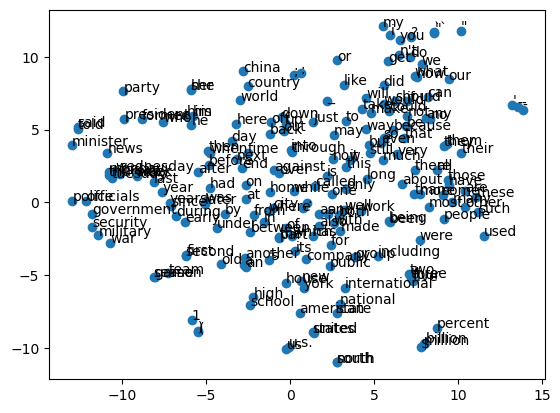

In [59]:
plt.scatter(Y[:, 0], Y[:, 1])
for label, x, y in zip(tokens, Y[:, 0], Y[:, 1]):
    plt.annotate(label, xy=(x, y), xytext=(0, 0), textcoords='offset points')
plt.show()

## Emotions

In [60]:
df=pd.read_csv("DrugiLemmEmotions.csv")
df.head()

,Unnamed: 0,label,Word_Count,Text_Lemm
0,0,4,8,helpless heavy hearted
1,1,0,45,ive enjoyed able slouch relax unwind frankly n...
2,2,4,12,gave internship dmrg distraught
3,3,0,7,dont know lost
4,4,4,42,kindergarten teacher thoroughly weary job take...


In [61]:
df.dropna(inplace=True)

In [63]:
from sklearn.model_selection import train_test_split

X=df['Text_Lemm']
y=df['label']
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2, random_state = 45)

In [64]:
#Tokenizacija, svaki token dobija svoj indeks
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=None)
tokenizer.fit_on_texts(X_train)

words_to_index = tokenizer.word_index

In [65]:
words_to_index

{'im': 1,
 'time': 2,
 'know': 3,
 'get': 4,
 'little': 5,
 'make': 6,
 'people': 7,
 'would': 8,
 'thing': 9,
 'want': 10,
 'one': 11,
 'day': 12,
 'think': 13,
 'still': 14,
 'life': 15,
 'even': 16,
 'ive': 17,
 'much': 18,
 'way': 19,
 'something': 20,
 'love': 21,
 'bit': 22,
 'dont': 23,
 'going': 24,
 'go': 25,
 'could': 26,
 'need': 27,
 'back': 28,
 'say': 29,
 'always': 30,
 'feeling': 31,
 'right': 32,
 'good': 33,
 'see': 34,
 'pretty': 35,
 'feel': 36,
 'work': 37,
 'also': 38,
 'year': 39,
 'friend': 40,
 'today': 41,
 'cant': 42,
 'never': 43,
 'help': 44,
 'around': 45,
 'didnt': 46,
 'though': 47,
 'come': 48,
 'well': 49,
 'made': 50,
 'someone': 51,
 'lot': 52,
 'look': 53,
 'thought': 54,
 'got': 55,
 'quite': 56,
 'every': 57,
 'week': 58,
 'happy': 59,
 'take': 60,
 'many': 61,
 'le': 62,
 'felt': 63,
 'find': 64,
 'home': 65,
 'anything': 66,
 'person': 67,
 'sure': 68,
 'kind': 69,
 'enough': 70,
 'last': 71,
 'left': 72,
 'actually': 73,
 'getting': 74,
 'witho

In [66]:
#recnik koji mapira reci na odgovarajuce vektore
def read_glove_vector(glove_vec):
  with open(glove_vec, 'r', encoding='UTF-8') as f:
    words = set()
    word_to_vec_map = {}
    for line in f:
      w_line = line.split()
      curr_word = w_line[0]
      word_to_vec_map[curr_word] = np.array(w_line[1:], dtype=np.float64)



  return word_to_vec_map

In [67]:
word_to_vec_map = read_glove_vector('glove.6B.50d.txt')

In [68]:
from tensorflow.keras.layers import Embedding

vocab_len = len(words_to_index)
embed_vector_len = word_to_vec_map['moon'].shape[0] #duzina vektora

emb_matrix = np.zeros((vocab_len, embed_vector_len))
ne_words=[]

for word, index in words_to_index.items():
  embedding_vector = word_to_vec_map.get(word)
  if embedding_vector is not None:
    emb_matrix[index, :] = embedding_vector
  else:
    ne_words.append(word)

embedding_layer = Embedding(input_dim=vocab_len, output_dim=embed_vector_len, weights = [emb_matrix], trainable=False)


In [69]:
ne_words

['hehy',
 'shouldnt',
 'hadnt',
 'youve',
 'werent',
 'itll',
 'nofollow',
 'theyve',
 'everyones',
 'theyll',
 'pagetitle',
 'cooky',
 'hehier',
 'ernate',
 'ogether',
 'wouldve',
 'unhehy',
 'hahaha',
 'permalink',
 'theyd',
 'ernative',
 'everythings',
 'anyones',
 'idk',
 'loyy',
 'isprivate',
 'languagedirection',
 'feedlinks',
 'pissy',
 'utf',
 'couldve',
 'shouldve',
 'ismobile',
 'mobileclass',
 'sucky',
 'crampy',
 'onclick',
 'ernately',
 'alittle',
 'oclock',
 'thatll',
 'clearboth',
 'bration',
 'becuz',
 'isprivateblog',
 'soooooo',
 'wehy',
 'bleh',
 'pmsing',
 'hahahaha',
 'hehcare',
 'achey',
 'completly',
 'smoothy',
 'allowfullscreen',
 'headachey',
 'whove',
 'frameborder',
 'ering',
 'moisturiser',
 'bloggy',
 'blogpost',
 'hahah',
 'incase',
 'examn',
 'whod',
 'fangirl',
 'ernatives',
 'ismobilerequest',
 'mustve',
 'bcoz',
 'goosebump',
 'peny',
 'prolly',
 'gne',
 'akward',
 'wholl',
 'dumbass',
 'ernating',
 'hehehe',
 'whelmed',
 'concious',
 'moisturising',


https://nlp.stanford.edu/pubs/glove.pdf <br>
https://github.com/sebtheiler/tutorials/tree/main/using-pretrained-glove-vectors <br>
https://towardsdatascience.com/sentiment-analysis-using-lstm-and-glove-embeddings-99223a87fe8e <br>
https://towardsdatascience.com/glove-research-paper-explained-4f5b78b68f89 <br>
https://www.baeldung.com/cs/co-occurrence-matrices